# LangGraph Sidecar Agent (Ollama + Playwright)

This notebook implements a template Sidecar Agent using LangGraph and Ollama.

The agent takes a source payload (e.g., a CVE record), optionally enriches

context with a Playwright-backed web tool, then synthesizes a final output

that combines the original input and the agent's response.

# Requirements:
- Ollama running locally with a suitable model pulled (default: gpt-oss:20b)
- Optional: SearXNG at http://127.0.0.1:8081 for search
- Playwright Chromium installed

# You can disable the web tool if SearXNG/Chromium are unavailable.


Install dependencies.

In [2]:
# Install required packages
# %pip install -q langgraph langchain-core langchain-ollama pydantic typing_extensions httpx unstructured lxml pandas nest_asyncio playwright

# # One-time browser install (safe to re-run)
# !playwright install chromium

Preflight testing.

In [3]:
# Imports, environment checks, and configuration
import os, json, textwrap, asyncio, re
from typing import Any, Dict, List, Optional, TypedDict

import nest_asyncio
nest_asyncio.apply()

DEFAULT_OLLAMA_MODEL = "gpt-oss:120b"
USE_WEB_TOOL = True  # flip to False if SearXNG/Chromium are not available

print({"model": DEFAULT_OLLAMA_MODEL, "use_web_tool": USE_WEB_TOOL})

{'model': 'gpt-oss:120b', 'use_web_tool': True}


Import playwright tool.

In [4]:
from playwright_tool import search_and_parse_web, direct_load

Set up Pydantic Classes.

In [18]:
# Define state models and validation
from pydantic import BaseModel, Field
from typing import Literal, TypedDict, Any, Dict, List, Optional

# agent response
class LLMOutputSegment(BaseModel):
    """The structured output from the LLM remediation analysis."""
    device_type: Literal["Gaming Console", "Media Server", "NAS", "PC", "Phone", "Printer", "Router", "Security Camera", "Smart Speaker", "Smart TV", "Streaming Box or Stick"] = Field(..., description="The generic category of device affected by the CVE.")
    # remediation node
    remediation_type: Literal["Update", "Configuration Change", "Password Update", "Uninstall", "Retire Device", "Disconnect", "Isolate", "No Fix"] = Field(..., description="Advice to the user \
                                                                                                                                                           who has this vunlerability on remediation. \
                                                                                                                                                           This describes what the step by step guide \
                                                                                                                                                           will instruct the user to do.")
    non_remediation_risk: str = Field(description="A short paragraph describing the risks of not remediating the vulnerability.")
    investigation_summary: str = Field(description="A summary of the investigation process, including search queries used and key findings from sources supporting the \
                                       remediation type, step by step guide, and non-remediation risks.")
    step_by_step_resolution: str = Field(description="Detailed step-by-step resolution instructions if RESOLVED.")
    vulnerable_versions: str = Field(description="A sentence or 2 explaining which versions of the device are vulnerable to this CVE.")

# nvd reference class
class NVDReferenceSegment(BaseModel):
    url: str = Field(..., description="The URL of the NVD reference.")
    content: str = Field(description="The full markdown content of the NVD reference.")

# final output
class SolutionSegment(BaseModel):
    # cve node
    cve_id: str = Field(..., description="The CVE identifier, e.g., CVE-2023-XXXX")
    cve_description: str = Field(..., description="A brief description of the CVE.")
    cvss_version: str = Field(..., description="The CVSS version used, e.g., V2 or V3.")
    cvss_score: float = Field(..., description="The CVSS numerical score.")
    cvss_severity: str = Field(..., description="The CVSS severity rating, e.g., LOW, MEDIUM, HIGH, CRITICAL.")
    # device node
    device_name: str = Field(..., description="The name of the affected device.")
    device_type: Literal["Gaming Console", "Media Server", "NAS", "PC", "Phone", "Printer", "Router", "Security Camera", "Smart Speaker", "Smart TV", "Streaming Box or Stick"] = Field(..., description="The generic category of device affected by the CVE.")
    # remediation node
    remediation_type: Literal["Update", "Configuration Change", "Password Update", "Uninstall", "Retire Device", "Disconnect", "Isolate", "No Fix"] = Field(..., description="Advice to the user \
                                                                                                                                                           who has this vunlerability on remediation.")
    non_remediation_risk: str = Field(description="A short paragraph describing the risks of not remediating the vulnerability.")
    investigation_summary: str = Field(description="A summary of the investigation process, including search queries used and key findings from sources supporting the \
                                       step by step guide.")
    step_by_step_resolution: str = Field(description="Detailed step-by-step resolution instructions if RESOLVED.")
    vulnerable_versions: str = Field(description="A sentence or 2 explaining which versions of the device are vulnerable to this CVE.")
    # references node
    nvd_references: List[NVDReferenceSegment] = Field(..., description="A list of all reference contents retrieved during the investigation from NVD.")

# side car state (static fields derived from the source)
class StaticSolutionSegment(BaseModel):
    cve_id: str = Field(..., description="The CVE identifier, e.g., CVE-2023-XXXX")
    cve_description: str = Field(..., description="A brief description of the CVE.")
    cvss_version: str = Field(..., description="The CVSS version used, e.g., V2 or V3.")
    cvss_score: float = Field(..., description="The CVSS numerical score.")
    cvss_severity: str = Field(..., description="The CVSS severity rating, e.g., LOW, MEDIUM, HIGH, CRITICAL.")
    # device node
    device_name: str = Field(..., description="The name of the affected device.")
    # references node
    nvd_references: List[NVDReferenceSegment] = Field(default_factory=list, description="A list of all reference contents retrieved during the investigation from NVD.")

# NEW: planner decision for iterative ReAct loop
class PlanDecision(BaseModel):
    action: Literal["search", "finalize"] = Field(..., description="search to perform another web query; finalize to produce the final solution.")
    query: Optional[str] = Field(None, description="The next search query when action == 'search'.")

# Graph state used by LangGraph
class GraphState(TypedDict, total=False):
    # original raw input (from file or upstream system)
    source: Dict[str, Any]
    # structured static fields projected from source
    static: StaticSolutionSegment
    # accumulated references
    nvd_references: List[NVDReferenceSegment]
    # agent output
    agent_output: LLMOutputSegment
    # web context (raw blocks)
    web_context: str
    # ReAct planner control
    next_action: Literal["search", "finalize"]
    next_query: Optional[str]
    steps: int
    # NEW: structured search log of queries by step
    search_log: List[Dict[str, Any]]
    # final structured solution
    final_solution: SolutionSegment

Main logic

Graph compiled (with iterative search + search_log).


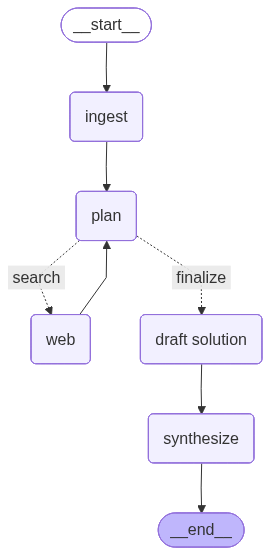

In [26]:
# Build the LangGraph workflow (ReAct-style with iterative search)
from langgraph.graph import StateGraph, END
from langchain_ollama import ChatOllama
from IPython.display import Image, display

# system prompt
SYSTEM_PROMPT = """
You are an expert Cybersecurity Researcher and Remediation Analyst.
Your goal is to use the provided CVE and context to identify **precise, and actionable technical resolution steps**.

### RESOLUTION CRITERIA:
- **RESOLVED:** If a fix exists, provide the exact version number to upgrade to, or the specific configuration command to run. Detail is crucial, but ensure it is *actionable* (e.g., "Upgrade to v1.2.3" is better than "Apply the latest patch").
- **UNRESOLVED:** If you confirm no fix exists (e.g., End-of-Life or 0-day with no patch), state clearly that it is unresolved and cite the vendor's statement if available. Ensure \
the remediaton type is "No Fix" in this case.

## Important
- Vulnerable Versions should be a sentence or two explaining what specific versions/configurations are vulnerable to this CVE.

## Final Goal
Given SOURCE fields and optional WEB_CONTEXT, produce a JSON object
matching the schema fields of LLMOutputSegment:
{
  "device_type": one of ["Gaming Console", "Media Server", "NAS", "PC", "Phone", "Printer", "Router", "Security Camera", "Smart Speaker", "Smart TV", "Streaming Box or Stick"],
  "remediation_type": one of ["Update","Configuration Change","Password Update","Uninstall","Retire Device","Disconnect","Isolate","No Fix"],
  "non_remediation_risk": str,
  "investigation_summary": str,
  "step_by_step_resolution": str,
  "vulnerable_versions": str
}
Return only JSON.
""".strip()

# max searches
MAX_STEPS = 3  # cap search iterations

import re, json, textwrap
from typing import Any, Dict, List

# Helpers to transform references formatted as <begin_page>... blocks
_PAGE_BLOCK_RE = re.compile(r"<begin_page>.*?<source url=(.*?)\s*/>\s*(.*?)</end_page>", re.DOTALL)

# populates NVDReferenceSegment lists appropriately from raw text blocks returned by web tool
def extract_references_from_blocks(blocks_text: str) -> List[NVDReferenceSegment]:
    refs: List[NVDReferenceSegment] = []
    if not blocks_text:
        return refs
    for match in _PAGE_BLOCK_RE.finditer(blocks_text):
        url = match.group(1).strip()
        content = match.group(2).strip()
        if url and content:
            try:
                refs.append(NVDReferenceSegment(url=url, content=content))
            except Exception:
                pass
    return refs

# populate the static solution segment (side car solution)
def build_static_from_source(source: Dict[str, Any]) -> StaticSolutionSegment:
    device_name = source.get("device") or source.get("device_name") or "Unknown Device"
    cve_id = source.get("cve_id") or "UNKNOWN-CVE"
    cve_description = source.get("description") or source.get("cve_description") or ""

    cvss_version = ""
    cvss_score = 0.0
    cvss_severity = ""
    score_data = source.get("score_data")
    if isinstance(score_data, list) and len(score_data) >= 3:
        cvss_version = str(score_data[0])
        try:
            cvss_score = float(score_data[1])
        except Exception:
            cvss_score = 0.0
        cvss_severity = str(score_data[2])

    initial_refs: List[NVDReferenceSegment] = []
    all_refs = source.get("all_references")
    if isinstance(all_refs, list):
        for block in all_refs:
            if isinstance(block, str):
                extracted = extract_references_from_blocks(block)
                initial_refs.extend(extracted)

    return StaticSolutionSegment(
        cve_id=cve_id,
        cve_description=cve_description,
        cvss_version=cvss_version or "",
        cvss_score=cvss_score,
        cvss_severity=cvss_severity or "",
        device_name=device_name,
        nvd_references=initial_refs,
    )

async def ingest_node(state: GraphState) -> GraphState:
    source = state.get("source", {})
    static = build_static_from_source(source or {})
    new_state = dict(state)
    new_state["static"] = static
    new_state["nvd_references"] = list(static.nvd_references or [])
    new_state["web_context"] = new_state.get("web_context", "")
    new_state["steps"] = int(new_state.get("steps", 0))
    new_state["next_action"] = "search"
    new_state["search_log"] = list(new_state.get("search_log", []))
    if isinstance(source, dict):
        seeded = source.get("description") or source.get("cve_id") or source.get("title")
        new_state["next_query"] = seeded
    return new_state  # type: ignore

async def web_node(state: GraphState) -> GraphState:
    if not USE_WEB_TOOL:
        print("[web_node] USE_WEB_TOOL is False; skipping web context.")
        return state
    query = state.get("next_query")
    if not query:
        print("[web_node] No query provided by planner; skipping.")
        return state
    step_no = int(state.get("steps", 0))
    print(f"[web_node] step={step_no} Querying SearXNG with: {query}")
    try:
        web_ctx = await search_and_parse_web(query=query, max_results=5)
        print(f"[web_node] Web context length: {len(web_ctx) if isinstance(web_ctx, str) else 'n/a'}")
    except Exception as e:
        print(f"[web_node] Error invoking search_and_parse_web: {e}")
        web_ctx = f"<web_tool_error>{e}</web_tool_error>"
    new_state = dict(state)
    prior = new_state.get("web_context", "") or ""
    new_state["web_context"] = f"{prior}\n\n{web_ctx}".strip()
    # Update structured search log
    log = list(new_state.get("search_log", []))
    log.append({"step": step_no, "query": str(query), "context_len": len(web_ctx) if isinstance(web_ctx, str) else None})
    new_state["search_log"] = log
    try:
        extra_refs = extract_references_from_blocks(web_ctx)
        print(f"[web_node] Extracted references from web context: {len(extra_refs)}")
        combined = list(new_state.get("nvd_references", [])) + extra_refs
        new_state["nvd_references"] = combined
        # Record ref count in log
        log[-1]["refs_extracted"] = len(extra_refs)
    except Exception as e:
        print(f"[web_node] Failed to extract references: {e}")
    return new_state  # type: ignore

async def plan_node(state: GraphState) -> GraphState:
    static: StaticSolutionSegment = state.get("static")  # type: ignore
    source = state.get("source", {})
    steps = int(state.get("steps", 0))

    def _compact(obj: Any) -> str:
        try:
            return json.dumps(obj, ensure_ascii=False)[:3000]
        except Exception:
            return str(obj)[:3000]

    web_snip = (state.get("web_context") or "")[-2000:]

    planner_system = "You are a planning assistant. Decide whether to SEARCH again or FINALIZE."
    planner_user = f"""
SOURCE (compact):
{_compact(source)}

STATIC FIELDS:
{_compact(static.model_dump()) if static else '{}'}

RECENT WEB CONTEXT (last 2000 chars):
{web_snip if web_snip else '(none)'}

Rules:
- If there is likely insufficient, conflicting, or no device-specific remediation info, action should be "search" with a focused query.
- If enough grounded details exist to produce the final structured remediation, action should be "finalize".
- Respond with JSON only:
{{"action": "search"|"finalize", "query": "<next query or empty>"}}
""".strip()
    
    # limiter
    if steps >= MAX_STEPS:
        new_state = dict(state)
        new_state["next_action"] = "finalize"
        new_state["next_query"] = None
        print(f"[plan_node] Max steps reached ({steps}); forcing finalize.")
        return new_state  # type: ignore

    llm = ChatOllama(model=DEFAULT_OLLAMA_MODEL, temperature=1.0, top_p=1.0, format="json")
    resp = await llm.ainvoke([("system", planner_system), ("user", planner_user)])
    content = getattr(resp, "content", "") if hasattr(resp, "content") else str(resp)

    json_text = content
    code_match = re.search(r"```json\s*(.*?)\s*```", content, re.DOTALL)
    if code_match:
        json_text = code_match.group(1)
    else:
        brace_match = re.search(r"\{.*\}\s*$", content, re.DOTALL)
        if brace_match:
            json_text = brace_match.group(0)

    action = "finalize"
    query = None
    try:
        parsed = json.loads(json_text)
        decision = PlanDecision(**parsed)
        action = decision.action
        query = decision.query
    except Exception:
        action = "finalize"
        query = None
        print(f"[plan_node] Failed to parse plan JSON, defaulting to finalize. Raw: {content[:200]}")

    new_state = dict(state)
    new_state["steps"] = steps + (1 if action == "search" else 0)
    new_state["next_action"] = action
    new_state["next_query"] = query
    print(f"[plan_node] step={steps} decision: action={action}, query={query!r}")
    return new_state  # type: ignore

async def draft_solution(state: GraphState) -> GraphState:
    static: StaticSolutionSegment = state.get("static")  # type: ignore
    source = state.get("source", {})

    def _compact(obj: Any) -> str:
        try:
            return json.dumps(obj, ensure_ascii=False)[:4000]
        except Exception:
            return str(obj)[:4000]

    web_ctx = state.get("web_context", "")
    context_snippet = web_ctx[:1200] if isinstance(web_ctx, str) else ""

    user_prompt = f"""
SOURCE (compact):
{source}

STATIC FIELDS:
{_compact(static.model_dump()) if static else '{}'}

WEB_CONTEXT (truncated):
{context_snippet if context_snippet else '(none)'}

Return only JSON for the LLMOutputSegment schema.
""".strip()

    llm = ChatOllama(model=DEFAULT_OLLAMA_MODEL, temperature=1.0, top_p=1.0)
    messages = [
        ("system", SYSTEM_PROMPT),
        ("user", user_prompt),
    ]
    resp = await llm.ainvoke(messages)
    content = getattr(resp, "content", "") if hasattr(resp, "content") else str(resp)

    json_text = content
    code_match = re.search(r"```json\s*(.*?)\s*```", content, re.DOTALL)
    if code_match:
        json_text = code_match.group(1)
    else:
        brace_match = re.search(r"\{.*\}\s*$", content, re.DOTALL)
        if brace_match:
            json_text = brace_match.group(0)

    try:
        parsed = json.loads(json_text)
        agent = LLMOutputSegment(**parsed)
    except Exception:
        agent = LLMOutputSegment(
            device_type="Unknown",
            remediation_type="No Fix",
            non_remediation_risk="The model returned unstructured content; unable to parse JSON.",
            investigation_summary=content.strip()[:2000],
            step_by_step_resolution="",
            vulnerable_versions="",
        )

    new_state = dict(state)
    new_state["agent_output"] = agent
    return new_state  # type: ignore

async def synthesize_node(state: GraphState) -> GraphState:
    static: StaticSolutionSegment = state.get("static")  # type: ignore
    agent: LLMOutputSegment = state.get("agent_output")  # type: ignore
    refs: List[NVDReferenceSegment] = state.get("nvd_references", [])  # type: ignore

    final = SolutionSegment(
        cve_id=static.cve_id,
        cve_description=static.cve_description,
        cvss_version=static.cvss_version,
        cvss_score=static.cvss_score,
        cvss_severity=static.cvss_severity,
        device_name=static.device_name,
        device_type=agent.device_type,
        remediation_type=agent.remediation_type,
        non_remediation_risk=agent.non_remediation_risk,
        investigation_summary=agent.investigation_summary,
        step_by_step_resolution=agent.step_by_step_resolution,
        vulnerable_versions=agent.vulnerable_versions,
        nvd_references=refs,
    )

    new_state = dict(state)
    new_state["final_solution"] = final
    return new_state  # type: ignore

# Wire the graph with a planning loop
workflow = StateGraph(GraphState)
workflow.add_node("ingest", ingest_node)
workflow.add_node("plan", plan_node)
workflow.add_node("web", web_node)
workflow.add_node("draft solution", draft_solution)
workflow.add_node("synthesize", synthesize_node)

workflow.set_entry_point("ingest")
workflow.add_edge("ingest", "plan")

def _route_from_plan(state: GraphState) -> str:
    if int(state.get("steps", 0)) >= MAX_STEPS and state.get("next_action") == "search":
        return "finalize"
    return "search" if state.get("next_action") == "search" else "finalize"

workflow.add_conditional_edges(
    "plan",
    _route_from_plan,
    {
        "search": "web",
        "finalize": "draft solution",
    },
)

workflow.add_edge("web", "plan")
workflow.add_edge("draft solution", "synthesize")
workflow.add_edge("synthesize", END)

app = workflow.compile()
print("Graph compiled (with iterative search + search_log).")

display(Image(app.get_graph().draw_mermaid_png()))

Execute the demo.

In [41]:
# Demo: load one sample and run the sidecar agent (iterative)
import pandas as pd
from pathlib import Path

SAMPLES = [
    Path("samples/sample.jsonl"),
    # Path("samples/discovered_cves.jsonl"),
]

sample_path = next((p for p in SAMPLES if p.exists()), None)
if not sample_path:
    raise FileNotFoundError("No sample.jsonl found in samples/. Please add one.")

# Read a single record
row = None
with open(sample_path, "r") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        try:
            row = json.loads(line)
            break
        except Exception:
            continue

if row is None:
    raise RuntimeError("Could not read a JSON object from the sample file.")

# Handle two common shapes in this repo's samples
if isinstance(row, dict) and len(row) == 1 and isinstance(next(iter(row.values())), list):
    device, items = next(iter(row.items()))
    source_payload = {
        "device": device,
        **(items[0] if items else {}),
    }
else:
    source_payload = row

initial_state: GraphState = {
    "source": source_payload,
    "steps": 0,  # enable planning loop
    "search_log": [],
}

print("Running graph with source keys:", list(source_payload.keys()))

result_state = await app.ainvoke(initial_state)

# Print the executed search queries clearly
search_log = result_state.get("search_log", [])  # type: ignore
print("\n=== Search Queries Executed ===")
if not search_log:
    print("(none)")
else:
    for ev in search_log:
        step_s = ev.get("step")
        q = ev.get("query")
        clen = ev.get("context_len")
        refs = ev.get("refs_extracted")
        print(f"- step {step_s}: {q}  (ctx_len={clen}, refs={refs})")

final: SolutionSegment = result_state.get("final_solution")  # type: ignore
print("\n=== Final Solution (Structured) ===\n")
print(final.model_dump_json(indent=2) if final else "<none>")

Running graph with source keys: ['device', 'cve_id', 'description', 'all_references', 'reference_links', 'score_data', 'config_data']
[plan_node] step=0 decision: action=finalize, query=''

=== Search Queries Executed ===
(none)

=== Final Solution (Structured) ===

{
  "cve_id": "CVE-2007-1220",
  "cve_description": "The Hypervisor in Microsoft Xbox 360 kernel 4532 and 4548 does not properly verify the parameters passed to the syscall dispatcher, which allows attackers with physical access to bypass code-signing requirements and execute arbitrary code.",
  "cvss_version": "V2",
  "cvss_score": 6.2,
  "cvss_severity": "MEDIUM",
  "device_name": "Microsoft Xbox",
  "device_type": "Gaming Console",
  "remediation_type": "Update",
  "non_remediation_risk": "If left unpatched, an attacker with physical access can exploit the hypervisor syscall parameter validation flaw to bypass code‑signing, gain hypervisor‑mode execution, run arbitrary unsigned code, install alternative operating systems

Test knowledge graph ingestion.

In [ ]:
from neo4j import GraphDatabase
import os

# 1. Configuration
URI = "bolt://localhost:7687"
AUTH = ("neo4j", "neo4j")  # Replace with your credentials

# 2. The Ingestion Function (The Core Logic)
def ingest_cve_data(tx, data: dict):
    """
    Ingests a single CVE solution segment into the graph using the 
    Triangle Pattern (Device -> Remediation -> CVE).
    """
    
    cypher_query = """
    // --- Step 1: Merge the Anchors (Device & CVE) ---
    // We use MERGE to find existing nodes or create them if missing.
    MERGE (c:CVE {cve_id: $cve_id})
    ON CREATE SET 
        c.description = $cve_description,
        c.cvss_version = $cvss_version,
        c.cvss_score = $cvss_score,
        c.cvss_severity = $cvss_severity
    
    MERGE (d:Device {device_name: $device_name})
    ON CREATE SET 
        d.type = $device_type

    // --- Step 2: Create the Remediation Node ---
    // We bind the solution to this specific Device-to-CVE pairing.
    MERGE (d)-[:HAS_SOLUTION]->(r:Remediation {
        remediation_type: $remediation_type,
        step_by_step: $step_by_step_resolution,
        non_remediation_risk: $non_remediation_risk,
        investigation_summary: $investigation_summary,
        vulnerable_versions: $vulnerable_versions, 
        // Note: You can map your risk_score logic here if you add it back later
        created_at: datetime()
    })

    // --- Step 3: Close the Triangle ---
    // Link Remediation back to CVE so we know exactly what it fixes.
    MERGE (r)-[:SOLVES]->(c)
    
    // Ensure the Device is linked to the CVE it suffers from.
    MERGE (c)-[:AFFECTS]->(d)

    // 1. UNWIND the list. 
    // This turns one row with a list of 5 references into 5 rows with 1 reference each.
    WITH c, d, $nvd_references AS refs
    UNWIND refs AS ref_item

    // 2. Create the Node using the properties from the object
    MERGE (ref:Reference {url: ref_item.url})
    ON CREATE SET 
        // Access the 'content' key from your JSON object
        ref.content = ref_item.content, 
        ref.created_at = datetime()

    // 3. Link it to the CVE (Not the Device)
    MERGE (c)-[:HAS_REFERENCE]->(ref)
    """
    
    # Execute the query passing the dictionary as parameters
    tx.run(cypher_query, **data)
    print(f"✅ Ingested {data['cve_id']} for {data['device_name']}")

def pydantic_helper(final: SolutionSegment) -> dict:
    return final.model_dump()

# 3. Execution Block
if __name__ == "__main__":
    # Your JSON Object (The Final Draft)

    # Connect and Run

    print(final.model_dump())

    try:
        with GraphDatabase.driver(URI, auth=AUTH) as driver:
            driver.verify_connectivity()
            with driver.session() as session:
                session.execute_write(ingest_cve_data, final.model_dump())
    except Exception as e:
        print(f"❌ Error: {e}")

{'cve_id': 'CVE-2007-1220', 'cve_description': 'The Hypervisor in Microsoft Xbox 360 kernel 4532 and 4548 does not properly verify the parameters passed to the syscall dispatcher, which allows attackers with physical access to bypass code-signing requirements and execute arbitrary code.', 'cvss_version': 'V2', 'cvss_score': 6.2, 'cvss_severity': 'MEDIUM', 'device_name': 'Microsoft Xbox', 'device_type': 'Gaming Console', 'remediation_type': 'Update', 'non_remediation_risk': 'If left unpatched, an attacker with physical access can exploit the hypervisor syscall parameter validation flaw to bypass code‑signing, gain hypervisor‑level execution, run arbitrary code or install unauthorized operating systems, resulting in full system compromise and loss of confidentiality, integrity, and availability.', 'investigation_summary': "CVE‑2007‑1220 is a hypervisor privilege‑escalation vulnerability in Xbox\u202f360 kernel versions 4532 and 4548. The hypervisor fails to fully validate the 64‑bit sysc